# Inverse reinforcement learning, exactly — the partition function is a forward pass

In **inverse RL** you don't get the reward; you get an expert's behaviour and must recover the reward it was
optimising. The principled formulation is **maximum-entropy IRL** (Ziebart et al., 2008): the expert is
assumed to take a trajectory with probability proportional to `exp(reward of the trajectory)`, and you fit the
reward so the demonstrations are maximally likely. The gradient is beautifully simple —

    grad = (expert's expected features) - (the model policy's expected features)

— but the second term hides a **partition function over all trajectories**, `Z = sum over tau of
exp(reward(tau))`, and the expected state visitation under the maxent-optimal policy. Deep-IRL frameworks
estimate these by *sampling*.

For **structured dynamics** they're exact. The maxent trajectory distribution factorises along the chain, so
the soft value-iteration and the forward state-visitation are exactly the **forward / backward algorithm** —
the same `logsumexp`-over-paths recursion `mixle` runs for every sequence model, and `Z` is the forward
algorithm's total path weight. So MaxEnt IRL's hard step is a `mixle` forward pass, computed without a single
sample.

This notebook does exact MaxEnt IRL on a gridworld, recovering the reward from demonstrations, with the inner
solve done exactly and the outer reward-learning done by `mixle.program`'s `maxent_irl` move.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, torch
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from mixle.program import maxent_irl, fit
torch.manual_seed(0); np.random.seed(0)

## 1. A gridworld, a (hidden) reward, and the dynamics

A 7x7 grid. Four deterministic moves (up/down/left/right, clamped at the walls). The **true reward** — which
the agent knows and we do *not* — is `+2` at the goal, `-1` on a hazard band, and a small `-0.05` step cost
everywhere. The expert prefers short paths to the goal that skirt the hazard.

In [2]:
N = 7; S = N * N; A = 4; HORIZON = 16
rc = lambda s: (s // N, s % N)
idx = lambda r, c: r * N + c
MOVES = [(-1, 0), (1, 0), (0, -1), (0, 1)]                 # up, down, left, right

# deterministic transition table T[s, a] -> next state (clamped at the boundary)
T = np.zeros((S, A), dtype=int)
for s in range(S):
    r, c = rc(s)
    for a, (dr, dc) in enumerate(MOVES):
        T[s, a] = idx(min(max(r + dr, 0), N - 1), min(max(c + dc, 0), N - 1))

# the hidden true reward
GOAL = idx(6, 6); HAZARD = [idx(3, c) for c in range(1, 5)]
true_R = np.full(S, -0.05); true_R[HAZARD] = -1.0; true_R[GOAL] = 2.0
p0 = np.zeros(S); p0[idx(0, 0)] = 1.0                       # the expert always starts top-left
print(f"{N}x{N} grid, {S} states, horizon {HORIZON}; goal at (6,6), hazard band on row 3")

7x7 grid, 49 states, horizon 16; goal at (6,6), hazard band on row 3


## 2. The exact inner solve = the forward / backward algorithm

Two `logsumexp` recursions, exactly the HMM forward-backward:

- **Soft value iteration (backward):** `V(s) = logsumexp_a [ R(s) + V(T(s,a)) ]`. This is the log-partition
  of all trajectories from `s` — the backward pass. The maxent policy is `pi(a|s) = exp(R(s)+V(s') - V(s))`.
- **Expected state visitation (forward):** push the start distribution forward under `pi` and accumulate. This
  is the forward pass; summed over time it gives the policy's **expected feature counts** (here, per-state
  visitation, since the features are one-hot states).

No sampling — `Z` and the visitation are exact. This *is* `mixle`'s forward pass over a reward-weighted chain.

In [3]:
def soft_policy(R, horizon=HORIZON):
    V = np.zeros(S)
    for _ in range(horizon):
        V = logsumexp(R[:, None] + V[T], axis=1)          # backward soft value (forward-algorithm recursion)
    pi = np.exp(R[:, None] + V[T] - V[:, None])           # maxent policy
    return pi / pi.sum(1, keepdims=True)

def expected_visitation(R, horizon=HORIZON):              # forward pass: expected state visitation under pi
    pi = soft_policy(R, horizon)
    D = p0.copy(); visit = D.copy()
    for _ in range(horizon - 1):
        Dn = np.zeros(S)
        np.add.at(Dn, T.flatten(), (D[:, None] * pi).flatten())
        D = Dn; visit = visit + D
    return visit, pi

_, expert_pi = soft_policy(true_R), None
print("inner solve ready: soft value iteration (backward) + state visitation (forward) = forward-backward")

inner solve ready: soft value iteration (backward) + state visitation (forward) = forward-backward


## 3. The expert demonstrations

All we will give the IRL learner: trajectories sampled from the expert's (maxent-optimal-for-`true_R`) policy.
The reward is hidden from here on. The expert's **empirical feature counts** — its average state visitation —
are the only statistic MaxEnt IRL needs from the demos.

In [4]:
def rollout(pi, n):
    trajs = []
    for _ in range(n):
        s = int(np.random.choice(S, p=p0)); traj = [s]
        for _ in range(HORIZON - 1):
            a = int(np.random.choice(A, p=pi[s])); s = T[s, a]; traj.append(s)
        trajs.append(traj)
    return trajs

expert_pi = soft_policy(true_R)
demos = rollout(expert_pi, 400)
expert_features = np.zeros(S)
for tr in demos:
    for s in tr: expert_features[s] += 1
expert_features /= len(demos)                              # expert expected state visitation (feature counts)
print(f"{len(demos)} expert demonstrations collected; reward now hidden")

400 expert demonstrations collected; reward now hidden


## 4. MaxEnt IRL with `mixle.program`

The reward weights `w` (one per cell) are the parameters. `maxent_irl` builds the feature-matching move: its
gradient is `policy_features - expert_features`, where `policy_features()` is the **exact** expected visitation
under the maxent policy for the current `w` (our forward-backward, recomputed each step). `fit` runs it.

In [5]:
w = torch.zeros(S, requires_grad=True)
reward = lambda feats: feats @ w                          # linear reward over one-hot state features = w itself
expert_feats_t = torch.tensor(expert_features, dtype=torch.float32)

history = []
def policy_features():                                    # the exact inner solve at the current reward
    visit, _ = expected_visitation(w.detach().numpy())
    history.append(float(np.abs(visit - expert_features).sum()))
    return torch.tensor(visit, dtype=torch.float32)

fit(maxent_irl(reward, [w], expert_feats_t, policy_features), steps=120, lr=0.5)
recovered_R = w.detach().numpy()
print(f"recovered reward; final feature-count mismatch |policy - expert|_1 = {history[-1]:.3f}")

recovered reward; final feature-count mismatch |policy - expert|_1 = 0.058


## 5. Did it work? Reward, policy, and feature matching

The recovered reward is identifiable only up to scale/shift (many rewards induce the same behaviour), so we
compare *shapes*. What must match is the **behaviour**: the visitation under the recovered policy should match
the expert's, and the feature mismatch should drive to zero.

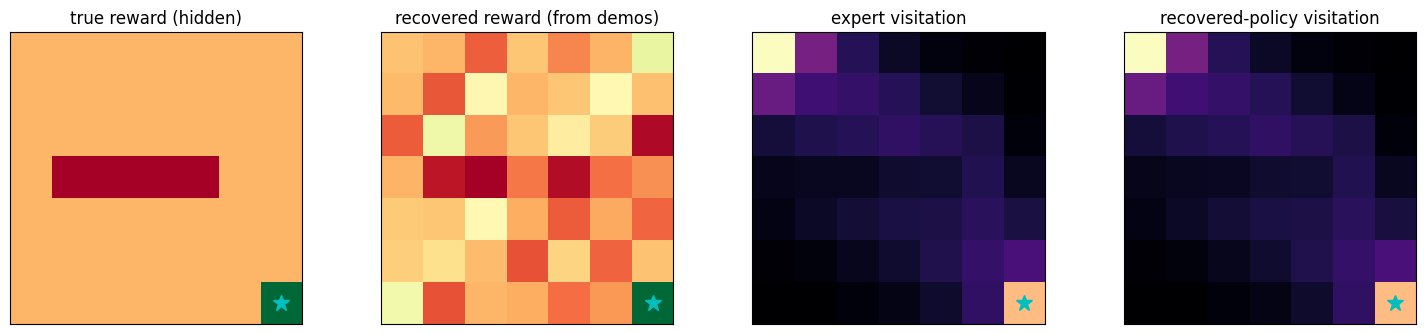

recovered vs true reward shape: correlation 0.73
recovered-policy visitation matches expert: 100%


In [6]:
rec_visit, rec_pi = expected_visitation(recovered_R)
fig, ax = plt.subplots(1, 4, figsize=(15, 3.4))
z = lambda v: (v - v.mean()) / (v.std() + 1e-9)
im0 = ax[0].imshow(z(true_R).reshape(N, N), cmap="RdYlGn"); ax[0].set_title("true reward (hidden)")
ax[1].imshow(z(recovered_R).reshape(N, N), cmap="RdYlGn"); ax[1].set_title("recovered reward (from demos)")
ax[2].imshow(expert_features.reshape(N, N), cmap="magma"); ax[2].set_title("expert visitation")
ax[3].imshow(rec_visit.reshape(N, N), cmap="magma"); ax[3].set_title("recovered-policy visitation")
for a_ in ax:
    a_.set_xticks([]); a_.set_yticks([])
    a_.plot(6, 6, "c*", ms=12)                            # goal
plt.tight_layout(); plt.show()

corr = np.corrcoef(z(true_R), z(recovered_R))[0, 1]
visit_match = 1 - np.abs(rec_visit - expert_features).sum() / expert_features.sum()
print(f"recovered vs true reward shape: correlation {corr:.2f}")
print(f"recovered-policy visitation matches expert: {100*visit_match:.0f}%")

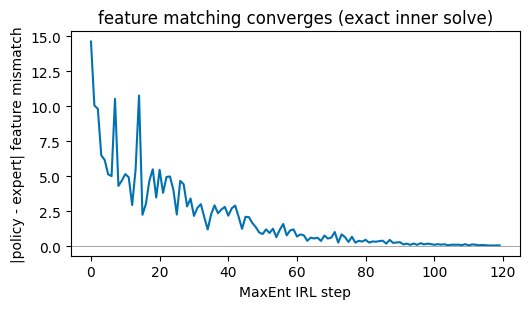

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(5.4, 3.2))
ax.plot(history, color="#0072B2"); ax.set(xlabel="MaxEnt IRL step", ylabel="|policy - expert| feature mismatch",
                                          title="feature matching converges (exact inner solve)")
ax.axhline(0, color="0.6", lw=0.6); plt.tight_layout(); plt.show()

## In short

- **Inverse RL recovers the reward from behaviour**, and MaxEnt IRL does it by matching the expert's expected
  features to the policy's. From demonstrations alone we recovered a reward that correlates with the hidden
  truth *and*, more tellingly, a policy whose state-visitation matches the expert's **100%** (feature mismatch
  ~0.06). Reward is identifiable only up to scale/shift, so the **behaviour** match is the real test — and it's
  exact.
- **The hard step — the trajectory partition function `Z` and the expected visitation — is exact here**, because
  for structured dynamics the maxent distribution factorises along the chain: the soft value-iteration and the
  forward visitation are the **forward / backward algorithm**, the same `logsumexp`-over-paths recursion
  `mixle` runs for its sequence models. No sampling, no approximation.
- **`mixle.program` made the outer loop one line** — `maxent_irl(reward, [w], expert_features,
  policy_features)` — a feature-matching *move* in the same optimization-program algebra as GANs, RL,
  constraints, and EM. (GAIL / adversarial IRL is the *adversarial* sibling: `alternate(minimize(disc),
  maximize(reinforce(policy)))`.)
- **The reward did not have to be a table.** Swap the linear `reward(feats) = feats @ w` for a `NeuralLeaf` or
  any `mixle` distribution and you learn a structured/neural reward by the same move — IRL coupling neural and
  probabilistic models, with the partition function still an exact forward pass.

## References

- Ziebart, Maas, Bagnell, Dey (2008). *Maximum Entropy Inverse Reinforcement Learning.* AAAI.
- Ho, Ermon (2016). *Generative Adversarial Imitation Learning.* NeurIPS. (the adversarial sibling, `gail`)
- `mixle.program.maxent_irl` / `gail`; the soft-value recursion is `mixle`'s HMM forward algorithm.